# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [162]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [163]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
print("Tỷ lệ missing của tất cả các cột")
print(df.isnull().mean())

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']  # điền danh sách cột cần bỏ (chỉ những cột có trong df)
df = df.drop(columns=leaky)    
# df = df.drop(columns=...)

# print("Các cột còn lại:", list(df.columns))
print("Các cột còn lại:", list(df.columns))

Tỷ lệ missing của tất cả các cột
survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

* Cột alive chính là cột mục tiêu survived (1/0) được viết lại bằng chữ.

* Thuật toán Machine Learning luôn tìm con đường tối ưu ngắn nhất. Khi thấy cột này, mô hình chỉ cần học đúng một quy luật đơn giản: Nếu alive là 'yes' thì survived là 1, ngược lại là 0. Nhờ vậy, nó dễ dàng đạt độ chính xác tuyệt đối mà không cần tốn công sức.

* Triệt tiêu khả năng học tập: Vì quá phụ thuộc vào cột alive, mô hình sẽ hoàn toàn không quan tâm và bỏ qua các thông tin cốt lõi thực sự quyết định đến sự sống chết của hành khách như `sex`, `age`, `pclass`.

* Mục tiêu của mô hình là dự đoán cho một hành khách mới (người mà chúng ta chưa biết họ sống hay chết, tức là không có sẵn cột alive). Khi mất đi cột này, mô hình sẽ hoàn toàn sụp đổ vì trước đó nó chưa từng học cách phân tích dữ liệu từ các đặc trưng khác.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [164]:
# TODO 2: shape, info, describe
print (f"Số dòng", df.shape[0])
print (f"Số cột", df.shape[1])
print (f"Biến mục tiêu là", 'survived')

df.info()

display (df.describe())

display(df.describe(include=['object', 'category']))


Số dòng 891
Số cột 8
Biến mục tiêu là survived
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**

a. Cột biến số:
Là những biến mà giá trị của chúng đại diện cho các phép đo lường hoặc đếm số lượng cụ thể:

* age : Biến số liên tục.

* fare: Biến số liên tục.

* sibsp: Biến số rời rạc.

* parch: Biến số rời rạc.

b. Cột biến phân loại:
Là những biến phân nhóm hành khách thành các danh mục riêng biệt:

* sex: Biến phân loại định danh nhị phân gồm male và female.

* embarked: Biến phân loại định danh gồm 3 nhóm S, C, Q.

* pclass: Biến phân loại có thứ bậc với 3 cấp độ 1, 2, 3.

* survived: Biến phân loại nhị phân nhận 2 giá trị sống/chết (1/0).

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [165]:
# TODO 3: bảng missing (count + %)
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({
    'Số lượng thiếu (Dòng)': missing_counts,
    'Phần trăm thiếu (%)': missing_pct
})

missing_df = missing_df[missing_df['Số lượng thiếu (Dòng)'] > 0].sort_values(by='Phần trăm thiếu (%)', ascending=False)
display(missing_df)

,Số lượng thiếu (Dòng),Phần trăm thiếu (%)
age,177,19.87
embarked,2,0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| age | ~19.87 | Điền giá trị trung vị (Median) hoặc dùng mô hình KNNImputer | Tuổi tác là đặc trưng quan trọng quyết định khả năng sống sót (ưu tiên trẻ em) nên không thể xóa bỏ cột này. Sử dụng median giúp hạn chế bị ảnh hưởng (nhiễu) bởi các outliers như hành khách quá già. Nếu dùng KNNImputer, thuật toán sẽ đoán tuổi thông minh hơn dựa trên các hành khách có cùng hạng vé (pclass) hoặc giới tính (sex). |
| embarked | ~0.22% | Điền bằng giá trị xuất hiện nhiều nhất (Mode) hoặc xóa bỏ 2 dòng này (Drop rows) | Tỷ lệ thiếu dữ liệu quá nhỏ (gần như không đáng kể) so với tổng số hơn 800 mẫu. Việc điền bằng mode diễn ra rất nhanh và hoàn toàn không làm thay đổi phân phối gốc của dữ liệu. Nếu chọn phương án xóa 2 dòng này cũng không gây mất mát thông tin đối với kích thước tập huấn luyện. |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [166]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    s_clean = s.dropna()
    Q1 = s_clean.quantile(0.25)
    Q3 = s_clean.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((s_clean < lower_bound) | (s_clean > upper_bound)).sum()

def dem_outlier_zscore(s, nguong=3.0):
    s_clean = s.dropna()
    z_scores = stats.zscore(s_clean)
    return (np.abs(z_scores) > nguong).sum()

for col in ["age", "fare"]:
    print(f"Thống kê Outlier cho cột '{col}'")
    print(f"Số outlier theo IQR: {dem_outlier_iqr(df[col])}")
    print(f"Số outlier theo Z-score (|z| > 3): {dem_outlier_zscore(df[col])}\n")

Thống kê Outlier cho cột 'age'
Số outlier theo IQR: 11
Số outlier theo Z-score (|z| > 3): 2

Thống kê Outlier cho cột 'fare'
Số outlier theo IQR: 116
Số outlier theo Z-score (|z| > 3): 20



**Trả lời 4 (quyết định với outlier của `fare`):**

Giữ lại.

Giải thích: Những outlier trong cột fare (giá vé) rất cao không phải là lỗi nhập liệu hay nhiễu mà là hiện tượng có thật. Tàu Titanic có sự phân cấp cực kỳ rõ ràng giữa các hạng vé (hạng 1, 2, 3). Việc có những hành khách thuộc giới tinh hoa, siêu giàu sẵn sàng trả mức giá cao để sở hữu các khoang hạng nhất xa hoa là điều hoàn toàn hợp lý.
Đặc biệt, fare có sự tương quan rất mạnh với khả năng sống sót (những người ở khoang hạng nhất có tỷ lệ được cứu cao hơn). Nếu chúng ta xóa bỏ những hành khách có fare cao bất thường này, chúng ta sẽ vô tình làm mất đi một lượng thông tin cực kỳ quan trọng để mô hình học tập, dẫn đến sai lệch thực tế.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

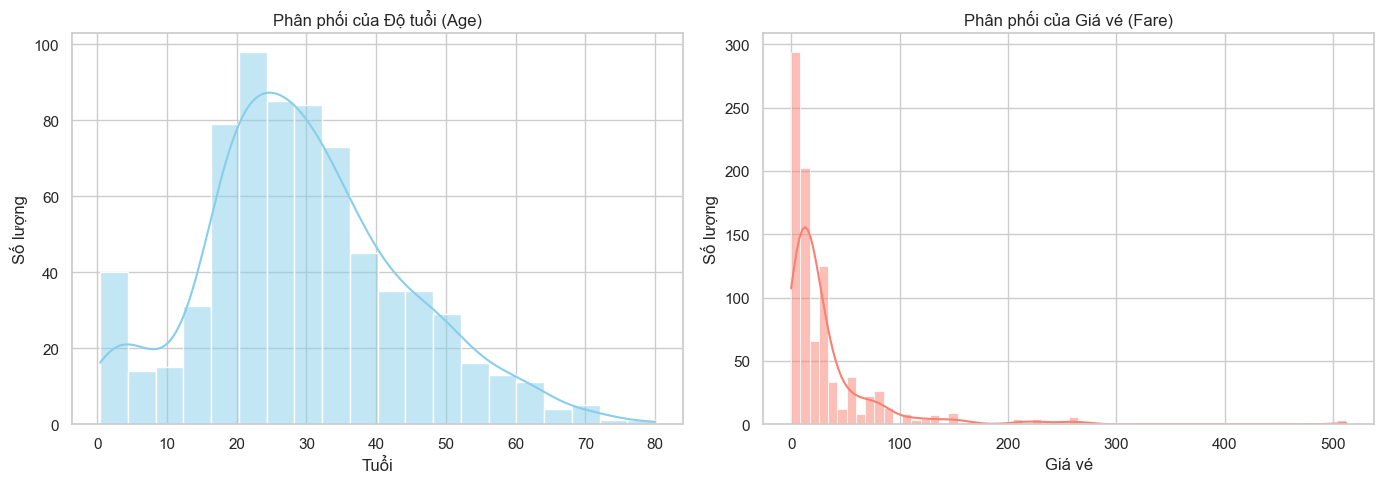

In [167]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x="age", kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Phân phối của Độ tuổi (Age)")
axes[0].set_xlabel("Tuổi")
axes[0].set_ylabel("Số lượng")

sns.histplot(data=df, x="fare", kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Phân phối của Giá vé (Fare)")
axes[1].set_xlabel("Giá vé")
axes[1].set_ylabel("Số lượng")

plt.tight_layout()
plt.show()

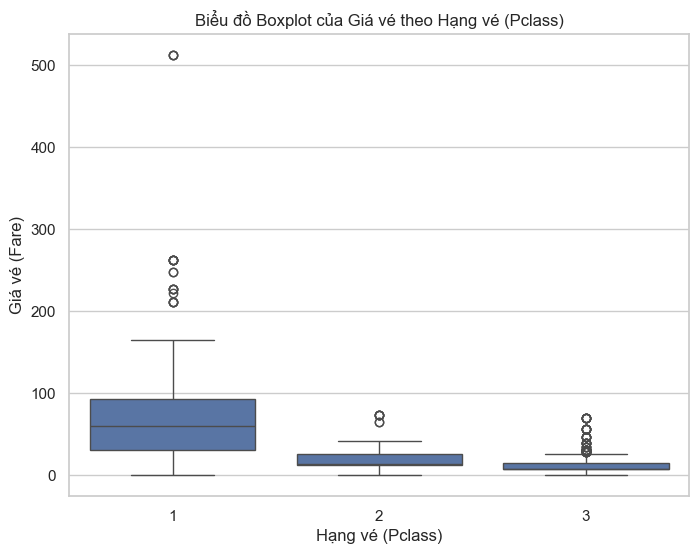

In [168]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="pclass", y="fare")
plt.title("Biểu đồ Boxplot của Giá vé theo Hạng vé (Pclass)")
plt.xlabel("Hạng vé (Pclass)")
plt.ylabel("Giá vé (Fare)")
plt.show()


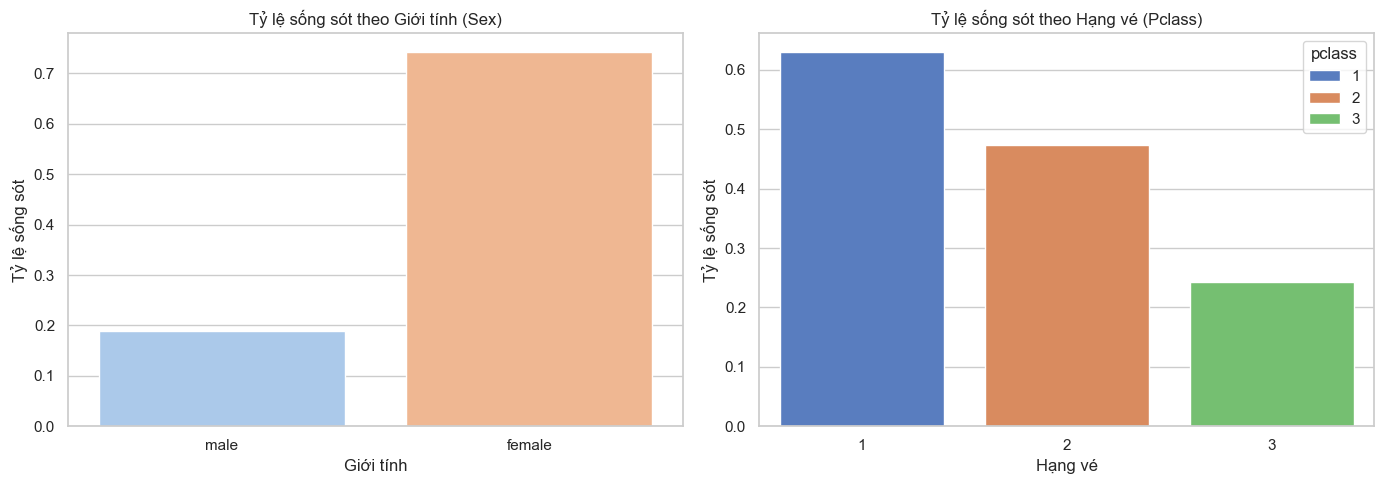

In [169]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x="sex", y="survived", ax=axes[0], errorbar=None, palette="pastel", hue = "sex")
axes[0].set_title("Tỷ lệ sống sót theo Giới tính (Sex)")
axes[0].set_xlabel("Giới tính")
axes[0].set_ylabel("Tỷ lệ sống sót")

sns.barplot(data=df, x="pclass", y="survived", ax=axes[1], errorbar=None, palette="muted", hue = "pclass")
axes[1].set_title("Tỷ lệ sống sót theo Hạng vé (Pclass)")
axes[1].set_xlabel("Hạng vé")
axes[1].set_ylabel("Tỷ lệ sống sót")

plt.tight_layout()
plt.show()

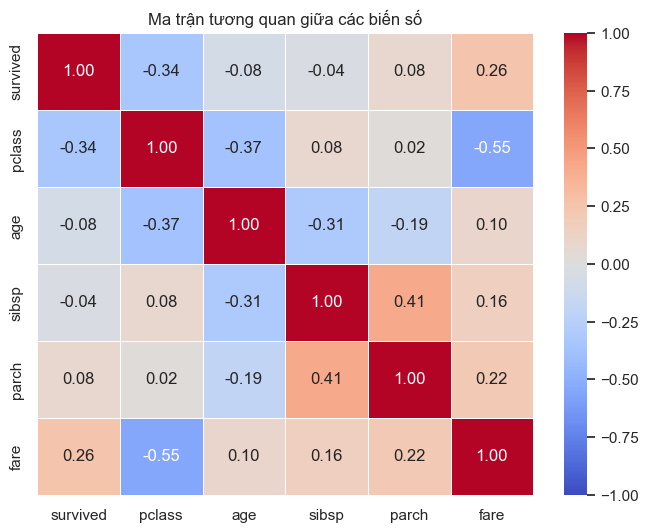

In [170]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(8, 6))
numerical_cols = df.select_dtypes(include=["number"])
sns.heatmap(numerical_cols.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Ma trận tương quan giữa các biến số")
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

-Histogram: 

* Biểu đồ age có phân phối tương đối chuẩn (gần như đối xứng) nhưng hơi lệch phải nhẹ, tập trung đông nhất ở độ tuổi lao động từ 20 đến 40 tuổi, và có một đỉnh nhỏ ở nhóm trẻ em.

* Biểu đồ fare có phân phối lệch phải cực kỳ nghiêm trọng. Hầu hết hành khách đều mua vé giá rẻ (dưới 50 USD), trong khi chỉ có một số rất ít hành khách mua vé hạng sang với mức giá cực cao (lên tới hơn 500 USD).

-Boxplot:
* Trung vị của giá vé giảm dần rõ rệt từ Hạng 1 xuống Hạng 3, phù hợp với thực tế chất lượng dịch vụ khoang tàu.

* Cả 3 hạng vé đều xuất hiện rất nhiều outliers nằm phía trên hộp, đặc biệt là ở Hạng 1 với những tấm vé có giá cao vượt trội, cho thấy sự phân hóa giàu nghèo sâu sắc ngay trong nhóm hành khách thượng lưu.

-Bar survival: 

* Theo giới tính: female có tỷ lệ sống sót vượt trội (~74%), cao hơn male (~19%) khoảng 55%. Điều này phản ánh ưu tiên cứu phụ nữ và trẻ em.

* Theo hạng vé: Tỷ lệ sống sót giảm dần theo hạng vé thấp hơn (Hạng 1 đạt hơn 60%, Hạng 2 khoảng 47%, còn Hạng 3 chỉ hơn 24%). Hành khách khoang hạng nhất được ưu tiên tiếp cận thuyền cứu sinh hơn khoang phổ thông.

-Heatmap:

* Cặp biến có tương quan mạnh nhất là sibsp và parch (0.41), cho thấy xu hướng những người đi cùng anh chị em/vợ chồng thì cũng thường đi cùng với cha mẹ/con cái (đi theo gia đình).

* Biến mục tiêu survived có mối tương quan âm rõ rệt nhất với pclass (-0.34), nghĩa là hạng vé càng tăng thì cơ hội sống sót càng giảm. Ngoài ra, survived tương quan dương với fare (0.26), củng cố thêm nhận định người mua vé đắt có cơ hội sống cao hơn.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [171]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=['survived'])
y = df['survived']

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=(0.15 / 0.85), random_state=42, stratify=y_tmp)

print("KÍCH THƯỚC CÁC TẬP DỮ LIỆU")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}\n")
print("TỶ LỆ SỐNG SÓT TRONG TỪNG TẬP")
print(f"Tập Train : {y_train.mean():.4f} (Số lượng: {y_train.sum()}/{len(y_train)})")
print(f"Tập Val   : {y_val.mean():.4f} (Số lượng: {y_val.sum()}/{len(y_val)})")
print(f"Tập Test  : {y_test.mean():.4f} (Số lượng: {y_test.sum()}/{len(y_test)})")

KÍCH THƯỚC CÁC TẬP DỮ LIỆU
X_train: (623, 7), y_train: (623,)
X_val:   (134, 7), y_val:   (134,)
X_test:  (134, 7), y_test:  (134,)

TỶ LỆ SỐNG SÓT TRONG TỪNG TẬP
Tập Train : 0.3836 (Số lượng: 239/623)
Tập Val   : 0.3881 (Số lượng: 52/134)
Tập Test  : 0.3806 (Số lượng: 51/134)


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [172]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder())
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)
print(X_train_t.shape, list(preprocess.get_feature_names_out()))


(623, 10) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Hàm .fit() là quá trình học hỏi và tính toán các tham số thống kê từ dữ liệu thực tế (như tìm tuổi trung vị, tìm mức giá vé cao nhất để chuẩn hóa).

Nếu .fit() trên toàn bộ dữ liệu trước khi chia: Ta đã vô tình cho mô hình xem trước đề thi (rò rỉ thông tin của tập Val và Test). Kết quả đánh giá sẽ bị cao ảo (quá lạc quan).

Vì vậy, chỉ .fit() trên tập Train: Để đảm bảo tập Val và Test hoàn toàn là dữ liệu mới chưa từng biết tới, mô phỏng đúng thực tế khi mô hình gặp khách hàng mới ngoài đời.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [173]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời

class_counts = df['survived'].value_counts()
class_ratios = df['survived'].value_counts(normalize=True) * 100

print("THỐNG KÊ BIẾN MỤC TIÊU SURVIVED")
print(f"Hành khách thiệt mạng (Lớp 0): {class_counts[0]} mẫu ({class_ratios[0]:.2f}%)")
print(f"Hành khách sống sót   (Lớp 1): {class_counts[1]} mẫu ({class_ratios[1]:.2f}%)")

THỐNG KÊ BIẾN MỤC TIÊU SURVIVED
Hành khách thiệt mạng (Lớp 0): 549 mẫu (61.62%)
Hành khách sống sót   (Lớp 1): 342 mẫu (38.38%)


**Trả lời 8:**

1. Mất cân bằng dữ liệu: Biến mục tiêu survived có sự mất cân bằng vừa phải. Tỷ lệ hành khách thiệt mạng chiếm đa số (~61.62%), trong khi tỷ lệ người sống sót chỉ chiếm khoảng 38.38%.

2. Điểm số Accuracy rất dễ đánh lừa chúng ta trong trường hợp dữ liệu bị mất cân bằng nghiêm trọng. Giả sử một bộ dữ liệu có 90% người chết và 10% người sống, một mô hình lười biếng chỉ cần đoán bừa tất cả mọi người đều chết thì Accuracy vẫn nghiễm nhiên đạt tới 90%. Tuy nhiên, mô hình này hoàn toàn vô dụng vì nó có tỷ lệ bắt được người sống sót là 0%.

3. Với bài toán cứu hộ Titanic, chúng ta nên ưu tiên sử dụng F1-Score làm thước đo chính, đi kèm với sự chú ý đặc biệt vào Recall.

* Recall cực kỳ quan trọng vì mục tiêu tối thượng trong cứu nạn là tìm kiếm và không bỏ sót bất kỳ ai có cơ hội sống sót (giảm thiểu sai lầm L2 - đoán một người sống thành chết).

* F1-Score đóng vai trò là một điểm số hài hòa (trung bình điều hòa) giúp cân bằng tốt giữa Precision (đoán chính xác người sống) và Recall (không bỏ sót người sống) trong bối cảnh dữ liệu đang bị lệch, đảm bảo mô hình phát triển một cách toàn diện.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Đặc trưng có tương quan tuyến tính mạnh nhất với khả năng sống sót (survived) là hạng vé pclass (hệ số tương quan âm khoảng -0.34) và giá vé fare (tương quan dương khoảng 0.26). Điều này chứng tỏ bằng chứng rõ ràng về giai cấp: hành khách ở khoang hạng nhất hoặc mua vé đắt tiền hơn có đặc quyền tiếp cận thuyền cứu sinh tốt hơn hẳn.
2. Cột bị khuyết thiếu trầm trọng nhất là age với tỷ lệ thiếu lên tới khoảng 19.87%. Vì đây là một biến số quan trọng, thay vì xóa bỏ cột, chiến lược xử lý được chọn là điền khuyết bằng giá trị trung vị. Việc dùng trung vị giúp đảm bảo giá trị điền vào an toàn và không bị kéo lệch bởi các hành khách có độ tuổi quá cao (outliers).
3. Biến mục tiêu survived có sự mất cân bằng rõ rệt khi nhóm thiệt mạng chiếm đa số (khoảng 61.62%), còn nhóm sống sót chỉ chiếm 38.38%. Sự chênh lệch này khiến thước đo Accuracy trở nên thiếu tin cậy vì mô hình có thể thiên vị lớp đa số. Do đó, cần ưu tiên sử dụng metric F1-Score và Recall để đo lường chính xác khả năng mô hình bắt được các trường hợp sống sót mà không bị bỏ lọt.
4. **Scaling (Chuẩn hóa):** Bắt buộc áp dụng cho các biến số (age, fare, sibsp, parch) để thu hẹp thang đo về cùng một dãy giá trị, tránh việc các cột có giá trị lớn (fare) áp đảo các cột nhỏ (age) trong các thuật toán tính khoảng cách. Riêng fare dùng RobustScaler để chống nhiễu từ vé siêu đắt. **Encoding (Mã hóa):** Bắt buộc áp dụng cho các biến phân loại định danh dạng chữ (sex, embarked) bằng OneHotEncoder, nhằm biến đổi văn bản thành các vector nhị phân (0 và 1) để thuật toán Machine Learning có thể hiểu và tính toán được toán học.

5. Sự kiện đắm tàu Titanic bộc lộ rõ nguyên tắc ưu tiên phụ nữ vượt lên trên cả ranh giới giàu nghèo. Biểu đồ cho thấy nữ giới có tỷ lệ sống sót áp đảo lên tới ~74%, cao hơn gấp nhiều lần so với mức chưa tới 20% của nam giới. Bất chấp một người đàn ông giàu có ở khoang hạng nhất, tỷ lệ sống của anh ta vẫn thấp hơn một người phụ nữ ở khoang bình dân.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

Hệ số tương quan tuyến tính giữa 'family_size' và 'survived': 0.0166



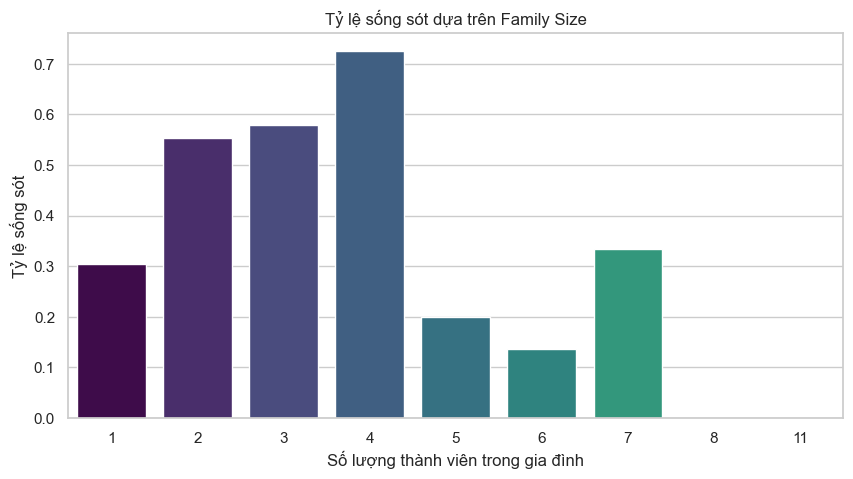

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns

df_bonus = df.copy()
df_bonus['family_size'] = df_bonus['sibsp'] + df_bonus['parch'] + 1
corr_value = df_bonus['family_size'].corr(df_bonus['survived'])
print(f"Hệ số tương quan tuyến tính giữa 'family_size' và 'survived': {corr_value:.4f}\n")
plt.figure(figsize=(10, 5))
sns.barplot(data=df_bonus, x='family_size', y='survived', hue='family_size', errorbar=None, palette='viridis', legend=False)

plt.title("Tỷ lệ sống sót dựa trên Family Size")
plt.xlabel("Số lượng thành viên trong gia đình")
plt.ylabel("Tỷ lệ sống sót")
plt.show()

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
